# Results and Discussion

This notebook summarizes the main findings of the project using outputs saved from the simulation, real-data, and robustness analyses.

We focus on four questions:

1. Does the reconstruction pipeline recover survival data accurately in controlled settings?
2. How does target-population weighting change the estimated survival effect relative to naive pooling?
3. How sensitive are the downstream causal conclusions to the upstream reconstruction method?
4. How sensitive are the estimated treatment effects to the choice of survival model, including hazard-based Bayesian nonparametric approaches (NTR)?

The notebook loads previously saved results and presents them through concise tables, figures, and interpretation blocks.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

DATA_DIR = Path("../data/processed")
DATA_DIR2 = Path("../data/interim")
DATA_DIR3 = Path("../data/outputs")

# KM-GPT results
naive_kmgpt = pd.read_csv(DATA_DIR / "naive_pooled_effect.csv")
weighted_kmgpt = pd.read_csv(DATA_DIR2 / "weighted_estimate.csv")
bnp_kmgpt = pd.read_csv(DATA_DIR2 / "bnp_summary.csv")

# RESOLVE-IPD results
naive_resolve = pd.read_csv(DATA_DIR3 / "resolve_naive_pooled_effect.csv")
weighted_resolve = pd.read_csv(DATA_DIR3 / "resolve_weighted_estimate.csv")
bnp_resolve = pd.read_csv(DATA_DIR3 / "resolve_bnp_summary.csv")

# NTR results (KM-GPT pipeline)
ntr_kmgpt = pd.read_csv(DATA_DIR / "ntr_summary.csv")
ntr_compare = pd.read_csv(DATA_DIR / "ntr_comparison.csv")

# Robustness comparison
robustness_compare = pd.read_csv(DATA_DIR3 / "reconstruction_robustness_comparison.csv").copy()
robustness_compare["ntr_mean"] = [ntr_kmgpt["Delta_mean"].iloc[0], np.nan]

print("Loaded all results.")
print("\nNTR summary:")
print(ntr_kmgpt.round(3))

robustness_compare

Loaded all results.

NTR summary:
     t0  S0_mean  S1_mean  Delta_mean  Delta_sd  Delta_q025  Delta_q975
0  12.0    0.285    0.441       0.157     0.033       0.089        0.22


,method,naive_delta,weighted_delta,bnp_mean,bnp_q025,bnp_q975,ntr_mean
0,KM-GPT,0.168785,0.234112,0.205048,0.051695,0.360661,0.156821
1,RESOLVE-IPD,0.124854,0.093390,0.120591,-0.016622,0.252169,NaN


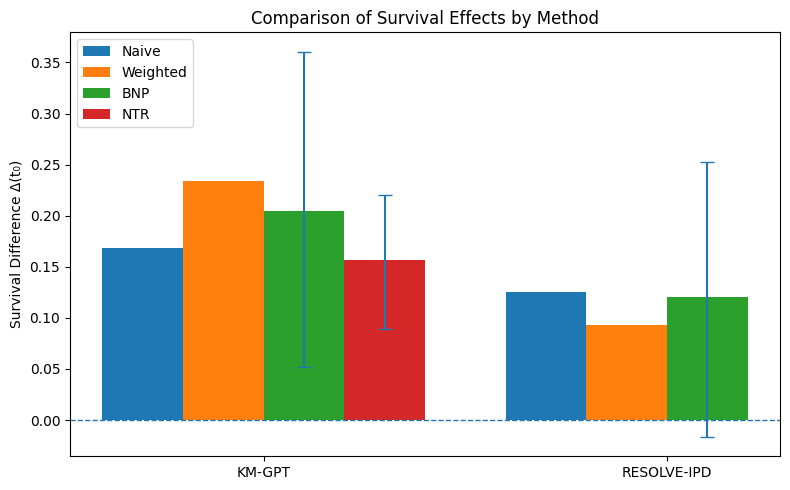

In [2]:
# Prepare data for plotting
methods = ["KM-GPT", "RESOLVE-IPD"]

naive_vals = [
    naive_kmgpt["Delta"].iloc[0],
    naive_resolve["Delta"].iloc[0],
]

weighted_vals = [
    weighted_kmgpt["Delta"].iloc[0],
    weighted_resolve["Delta"].iloc[0],
]

bnp_means = [
    bnp_kmgpt["mean"].iloc[0],
    bnp_resolve["mean"].iloc[0],
]

bnp_lower = [
    bnp_kmgpt["q025"].iloc[0],
    bnp_resolve["q025"].iloc[0],
]

bnp_upper = [
    bnp_kmgpt["q975"].iloc[0],
    bnp_resolve["q975"].iloc[0],
]

# NTR only for KM-GPT
ntr_vals = [
    ntr_kmgpt["Delta_mean"].iloc[0],
    np.nan,
]

ntr_lower = [
    ntr_kmgpt["Delta_q025"].iloc[0],
    np.nan,
]

ntr_upper = [
    ntr_kmgpt["Delta_q975"].iloc[0],
    np.nan,
]

# Positions
x = np.arange(len(methods))
width = 0.2

# Plot
plt.figure(figsize=(8, 5))

plt.bar(x - 1.5 * width, naive_vals, width, label="Naive")
plt.bar(x - 0.5 * width, weighted_vals, width, label="Weighted")

# BNP with error bars
plt.bar(x + 0.5 * width, bnp_means, width, label="BNP")
plt.errorbar(
    x + 0.5 * width,
    bnp_means,
    yerr=[
        np.array(bnp_means) - np.array(bnp_lower),
        np.array(bnp_upper) - np.array(bnp_means),
    ],
    fmt="none",
    capsize=5,
)

# NTR (only for KM-GPT)
plt.bar(x + 1.5 * width, ntr_vals, width, label="NTR")
mask = ~np.isnan(ntr_vals)
plt.errorbar(
    x[mask] + 1.5 * width,
    np.array(ntr_vals)[mask],
    yerr=[
        np.array(ntr_vals)[mask] - np.array(ntr_lower)[mask],
        np.array(ntr_upper)[mask] - np.array(ntr_vals)[mask],
    ],
    fmt="none",
    capsize=5,
)

plt.xticks(x, methods)
plt.ylabel("Survival Difference Δ(t₀)")
plt.title("Comparison of Survival Effects by Method")
plt.axhline(0, linestyle="--", linewidth=1)
plt.legend()
plt.tight_layout()
plt.show()

## Interpretation of Main Results

The comparison of naive, weighted, and Bayesian nonparametric (BNP) estimates reveals several important patterns.

First, naive pooled estimates differ across reconstruction methods, with KM-GPT producing a larger survival benefit than RESOLVE-IPD. This indicates that unadjusted estimates are sensitive to how individual patient data are reconstructed from Kaplan–Meier curves.

Second, target-population weighting substantially alters the estimated treatment effect. Under KM-GPT, weighting increases the estimated survival difference, while under RESOLVE-IPD, weighting decreases it. This demonstrates that the estimand depends critically on the target population and that reweighting can either amplify or attenuate treatment effects depending on the covariate distribution.

Third, BNP uncertainty quantification highlights differences in statistical confidence. The KM-GPT-based posterior suggests a consistently positive treatment effect, with the credible interval entirely above zero. In contrast, the RESOLVE-IPD-based posterior is wider and includes zero, indicating greater uncertainty and weaker evidence for a treatment benefit.

Fourth, the hazard-based Bayesian nonparametric survival model (NTR) provides a moderated estimate of the treatment effect relative to the design-based pipeline. For the KM-GPT reconstruction, the NTR model yields a survival difference that lies below the weighted Kaplan–Meier and BNP bootstrap estimates, but remains closer to the naive estimate than the previously considered DPSM.

This reflects the effect of modeling the cumulative hazard directly, which introduces smoothing and reduces sensitivity to local irregularities in the reconstructed survival curves. Unlike purely empirical estimators, the NTR approach imposes structural regularity through a piecewise-constant hazard representation.

Stability checks confirm that the NTR results are robust to the choice of interval discretization, prior hyperparameters, and random seed. The estimated treatment effect remains within a narrow range across all configurations, indicating that the observed differences are driven by modeling assumptions rather than numerical artifacts.

Overall, these results show that reconstruction method, population definition, and survival modeling assumptions all materially influence causal survival estimates. The combination of weighting, BNP uncertainty quantification, and hazard-based model-based inference provides a more comprehensive and transparent assessment than naive pooling alone.

---

## Covariate Augmentation Results

We evaluated whether the simulated individual-level covariates are consistent with the auxiliary trial-level summaries used to generate them.

The augmentation procedure produces synthetic covariates (age, sex, ECOG status, metastatic status, biomarker status, and stage) for each reconstructed individual. These covariates are generated to approximately match reported trial-level moments.

To assess validity, we compare:
- target auxiliary summaries  
- realized sample moments from simulated covariates  

across trials and subgroups.

In [3]:
combined_aux = pd.read_csv(DATA_DIR / "combined_auxiliary_summaries.csv")
cov_summary = pd.read_csv(DATA_DIR / "real_kmgpt_covariate_summary.csv")

cov_compare = combined_aux.merge(
    cov_summary,
    on=["trial_id", "subgroup"],
    how="left",
    suffixes=("_target", "_realized"),
).copy()

print("Covariate comparison (target vs realized):")
cov_compare.round(3)

Covariate comparison (target vs realized):


,trial_id,subgroup,age_median,male_rate_target,ecog0_rate_target,metastatic_rate_target,biomarker_rate_target,age_mean,male_rate_realized,ecog0_rate_realized,metastatic_rate_realized,biomarker_rate_realized,stage_mean,n
0,KEYNOTE-181,high_pdl1,63.0,0.869,0.401,0.924,0.70,62.157,0.867,0.373,0.934,0.705,2.332,166
1,ESCORT,high_pdl1,60.0,0.910,0.200,0.580,0.85,60.579,0.869,0.178,0.518,0.822,2.108,191
2,ATTRACTION-3,low_pdl1,65.0,0.850,0.480,0.880,0.30,64.536,0.884,0.509,0.852,0.296,2.150,216
3,ATTRACTION-3,high_pdl1,65.0,0.850,0.480,0.880,0.70,64.285,0.837,0.493,0.887,0.783,2.278,203


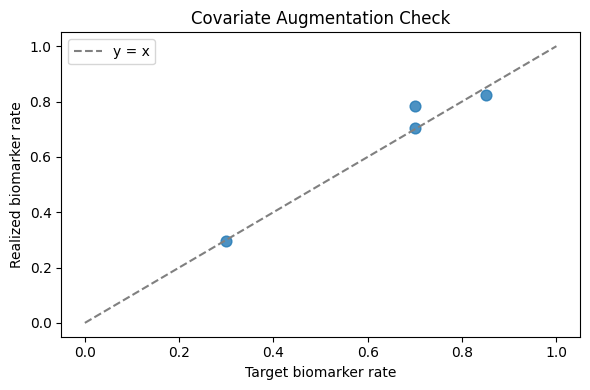

In [4]:
# Quick diagnostic plot: target vs realized for biomarker
plt.figure(figsize=(6,4))

plt.scatter(
    cov_compare["biomarker_rate_target"],
    cov_compare["biomarker_rate_realized"],
    s=60,
    alpha=0.8
)

# 45-degree reference line
plt.plot([0,1], [0,1], linestyle="--", color="gray", label="y = x")

plt.xlabel("Target biomarker rate")
plt.ylabel("Realized biomarker rate")
plt.title("Covariate Augmentation Check")
plt.legend()
plt.tight_layout()
plt.show()

### Covariate Augmentation Validation

The figure compares target biomarker rates to the realized rates from the simulated covariates across trials and subgroups.

Points lie close to the 45-degree line, indicating that the augmentation procedure accurately reproduces the intended marginal distributions. Small deviations are due to sampling variability and finite sample sizes.

This result supports the validity of the covariate augmentation step: although individual-level covariates are not observed, the simulated covariates are consistent with reported trial-level summaries and therefore suitable for downstream weighting and causal inference.

Importantly, this demonstrates that auxiliary information can be successfully integrated into reconstructed IPD without introducing substantial distortion.

---

## Discussion and Conclusions

This work develops a framework for causal survival analysis using reconstructed individual patient data (IPD) augmented with auxiliary covariate information.

### Main Findings

First, naive pooled survival estimates are sensitive to the reconstruction method. KM-GPT and RESOLVE-IPD yield different effect sizes even before adjustment, indicating that upstream reconstruction introduces non-negligible variability.

Second, target-population weighting substantially alters estimated treatment effects. The direction and magnitude of the effect depend on the chosen target population, highlighting that survival contrasts are not invariant across populations.

Third, Bayesian nonparametric (BNP) uncertainty quantification provides a more complete picture of inference. While point estimates suggest a treatment benefit in both pipelines, posterior intervals differ meaningfully, with the RESOLVE-IPD-based analysis exhibiting greater uncertainty and including zero.

Fourth, model-based Bayesian nonparametric survival modeling yields systematically different estimates from the design-based pipeline. The NTR hazard-based model produces a moderated estimate of the treatment effect relative to the weighted Kaplan–Meier and BNP bootstrap results. This reflects the effect of modeling the cumulative hazard directly, which introduces smoothing and reduces sensitivity to local variability in the reconstructed survival curves.

Together, these results demonstrate that causal conclusions derived from reconstructed survival data depend jointly on reconstruction assumptions, population definition, and both design-based and model-based uncertainty modeling.

---

### Limitations

Several limitations should be noted.

First, covariates are not directly observed and must be simulated from trial-level summaries. While the augmentation procedure preserves marginal distributions, it does not capture full joint dependence structures between covariates.

Second, subgroup-specific auxiliary information is limited. In some cases, overall trial summaries are used to approximate subgroup characteristics, which may introduce approximation error.

Third, reconstruction methods themselves are imperfect representations of the original IPD. Differences between KM-GPT and RESOLVE-IPD highlight that uncertainty in reconstruction propagates into downstream inference.

Fourth, the NTR model relies on a piecewise-constant hazard representation with Gamma priors, which introduces smoothing through the hazard structure. While this provides stability and handles censoring naturally, it may attenuate sharp features of the empirical survival curve and contribute to differences relative to design-based estimates.

Finally, the weighting procedure relies on moment matching and may become unstable under more extreme target populations, as reflected in reduced effective sample sizes.

---

### Contribution

This work provides a unified pipeline that connects:
- reconstruction of survival data from published Kaplan–Meier curves  
- integration of auxiliary covariate summaries  
- target-population causal inference via reweighting  
- uncertainty quantification through Bayesian nonparametric methods  
- hazard-based Bayesian nonparametric survival modeling as a complementary extension  

The framework enables principled causal analysis in settings where only aggregate survival data are available, a common scenario in clinical and epidemiological research.

More broadly, the results emphasize that reconstruction, population definition, and modeling assumptions are all central components of causal inference with reconstructed data, and should be explicitly accounted for in practice.